<a href="https://colab.research.google.com/github/hwasun-zip/yamyam/blob/main/yamyam_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import re

DIR = "/content/drive/MyDrive/foodrec_data"

def read_any(path, **kw):
    for enc in ("cp949", "utf-8-sig", "utf-8"):
        try:
            return pd.read_csv(path, encoding=enc, **kw)
        except UnicodeDecodeError:
            continue
    raise ValueError("인코딩 실패: " + path)

# ── 1) 검색 트렌드 (메타데이터 줄은 건너뛰고, 날짜 형식인 행만 추림) ──
raw = read_any(f"{DIR}/datalab.csv", header=None, dtype=str)
mask = raw[0].astype(str).str.match(r"\d{4}-\d{2}-\d{2}")
foods = ["국밥", "칼국수", "냉면", "파전", "팥빙수"]
s = raw.loc[mask].iloc[:, :10].copy()
s.columns = ["date", "국밥", "d2", "칼국수", "d3", "냉면", "d4", "파전", "d5", "팥빙수"]
trend = s[["date"] + foods].copy()
trend["date"] = pd.to_datetime(trend["date"])
for f in foods:
    trend[f] = pd.to_numeric(trend[f], errors="coerce")

# ── 2) 날씨 (날짜 형식인 행만 추림) ──
wraw = read_any(f"{DIR}/OBS_ASOS_DD_20260715004908.csv", header=None, dtype=str)
wmask = wraw[2].astype(str).str.match(r"\d{4}-\d{2}-\d{2}")
w = wraw.loc[wmask].iloc[:, :7].copy()
w.columns = ["지점", "지점명", "date", "기온", "강수", "풍속", "습도"]
w["date"] = pd.to_datetime(w["date"])
for c in ["기온", "강수", "풍속", "습도"]:
    w[c] = pd.to_numeric(w[c], errors="coerce")
w["강수"] = w["강수"].fillna(0.0)          # 비 안 온 날은 결측 → 0
w["비온날"] = (w["강수"] > 0).astype(int)

# ── 3) 날짜로 결합 ──
df = trend.merge(w[["date", "기온", "강수", "습도", "풍속", "비온날"]], on="date", how="inner")
print("결합 결과:", df.shape[0], "일 /", df["date"].min().date(), "~", df["date"].max().date())

# ── 4) 상관: 각 음식 검색량 vs 날씨 ──
corr = df[foods + ["기온", "강수", "습도", "풍속"]].corr()
print("\n[음식 검색량 ↔ 날씨 상관계수]")
print(corr.loc[foods, ["기온", "강수", "습도", "풍속"]].round(2).to_string())

# ── 5) 비 오는 날 효과 (파전 검증) ──
print("\n[비 여부별 평균 검색지수]")
print(df.groupby("비온날")[foods].mean().round(1).to_string())

Mounted at /content/drive
결합 결과: 974 일 / 2023-01-01 ~ 2025-08-31

[음식 검색량 ↔ 날씨 상관계수]
       기온    강수    습도    풍속
국밥  -0.12 -0.02  0.03  0.02
칼국수 -0.11  0.21  0.21  0.08
냉면   0.71 -0.02  0.07 -0.10
파전   0.08  0.53  0.30  0.14
팥빙수  0.73  0.09  0.25 -0.12

[비 여부별 평균 검색지수]
       국밥   칼국수    냉면   파전  팥빙수
비온날                            
0    30.1  30.5  24.5  2.8  5.9
1    30.6  36.0  22.6  5.4  7.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 22.4 MB/s eta 0:00:00


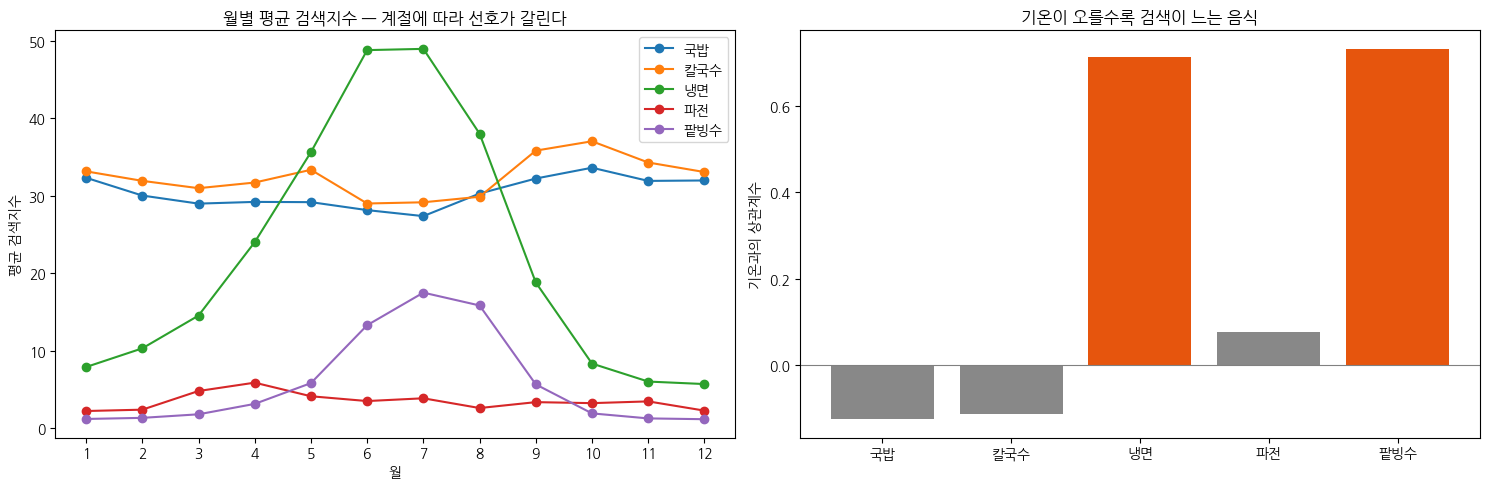

In [2]:
!pip install koreanize-matplotlib -q
import koreanize_matplotlib
import matplotlib.pyplot as plt

df["월"] = df["date"].dt.month
monthly = df.groupby("월")[foods].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for f in foods:
    axes[0].plot(monthly.index, monthly[f], marker="o", label=f)
axes[0].set_xlabel("월"); axes[0].set_ylabel("평균 검색지수")
axes[0].set_title("월별 평균 검색지수 — 계절에 따라 선호가 갈린다")
axes[0].set_xticks(range(1, 13)); axes[0].legend()

tcorr = df[foods + ["기온"]].corr()["기온"][foods]
axes[1].bar(foods, tcorr, color=["#888" if abs(v) < 0.3 else "#e6550d" for v in tcorr])
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].set_ylabel("기온과의 상관계수")
axes[1].set_title("기온이 오를수록 검색이 느는 음식")

plt.tight_layout(); plt.show()

In [4]:
# 음식점 파일: 깨진 바이트는 대체(replace)하며 cp949로 읽기
r = pd.read_csv(f"{DIR}/서울시 일반음식점 인허가 정보.csv",
                header=None, dtype=str, low_memory=False,
                encoding="cp949", encoding_errors="replace")
r = r[r[0].astype(str).str.match(r"\d+")].copy()          # 헤더 행 제거

cols = {4:"영업상태", 6:"상세상태", 11:"지번주소", 12:"도로명주소", 14:"상호", 18:"업태", 19:"X", 20:"Y"}
rest = r[list(cols)].copy()
rest.columns = list(cols.values())

addr = rest["지번주소"].fillna("") + " " + rest["도로명주소"].fillna("")
gn = rest[addr.str.contains("강남구", na=False)].copy()
print("강남구 행 수:", len(gn))

print("\n[영업상태 값]"); print(gn["영업상태"].value_counts().head())
print("\n[상세상태 값]"); print(gn["상세상태"].value_counts().head())
print("\n[업태 상위 15]"); print(gn["업태"].value_counts().head(15).to_string())

kw = {"국밥":["국밥"], "칼국수":["칼국수"], "냉면":["냉면"],
      "파전":["파전","부침","전집"], "팥빙수":["빙수","팥빙"]}
print("\n[상호명 키워드 매칭 수]")
for f, keys in kw.items():
    m = gn["상호"].fillna("").str.contains("|".join(keys), na=False)
    print(f, int(m.sum()))

강남구 행 수: 50994

[영업상태 값]
영업상태
폐업       38735
영업/정상    12259
Name: count, dtype: int64

[상세상태 값]
상세상태
폐업    38735
영업    12259
Name: count, dtype: int64

[업태 상위 15]
업태
한식                 19478
경양식                12016
분식                  5503
기타                  4747
일식                  3200
중국식                 1404
패스트푸드                890
호프/통닭                788
통닭(치킨)               573
외국음식전문점(인도,태국등)      469
까페                   388
정종/대포집/소주방           349
김밥(도시락)              288
뷔페식                  185
전통찻집                 138

[상호명 키워드 매칭 수]
국밥 177
칼국수 447
냉면 128
파전 17
팥빙수 13


In [5]:
!pip install pyproj -q
from pyproj import Transformer

op = gn[gn["상세상태"] == "영업"].copy()
op["X"] = pd.to_numeric(op["X"], errors="coerce")
op["Y"] = pd.to_numeric(op["Y"], errors="coerce")
op = op[(op["X"] > 0) & (op["Y"] > 0)].copy()

tf = Transformer.from_crs("EPSG:5174", "EPSG:4326", always_xy=True)
op["lon"], op["lat"] = tf.transform(op["X"].values, op["Y"].values)

print("영업중 + 좌표 있는 강남구 음식점:", len(op))
print("\n좌표 샘플 (강남이면 위도 37.5, 경도 127.0 근처여야 정상):")
print(op[["상호", "lat", "lon"]].head().to_string(index=False))

print("\n[음식별 후보 수 — 영업중 기준]")
for f, keys in kw.items():
    m = op["상호"].fillna("").str.contains("|".join(keys), na=False)
    print(f, int(m.sum()))

영업중 + 좌표 있는 강남구 음식점: 10932

좌표 샘플 (강남이면 위도 37.5, 경도 127.0 근처여야 정상):
         상호       lat        lon
       다미카츠 37.485681 127.045388
       정담은찬 37.493661 127.060397
 잭슨피자(압구정점) 37.524958 127.024603
이자카야 우규 역삼점 37.501338 127.033153
     스시 하쿠샤 37.510377 127.056190

[음식별 후보 수 — 영업중 기준]
국밥 68
칼국수 87
냉면 21
파전 6
팥빙수 3


In [9]:
from sklearn.linear_model import LinearRegression

Wcols = ["기온", "강수", "습도", "풍속"]
dfm = df.dropna(subset=Wcols + foods).copy()   # 결측 있는 날 제외
print("모델 학습에 쓴 날:", len(dfm), "/ 전체", len(df))

models, mu, sd = {}, {}, {}
for f in foods:
    m = LinearRegression().fit(dfm[Wcols], dfm[f])
    models[f] = m
    pred = m.predict(dfm[Wcols])
    mu[f], sd[f] = pred.mean(), pred.std()

def food_scores(기온, 강수, 습도, 풍속):
    x = [[기온, 강수, 습도, 풍속]]
    out = {f: (models[f].predict(x)[0] - mu[f]) / sd[f] for f in foods}
    return dict(sorted(out.items(), key=lambda kv: -kv[1]))

tests = {
    "덥고 맑음 (33도, 비0, 습도60, 풍속2)":   (33, 0, 60, 2),
    "비오고 선선 (18도, 비20, 습도90, 풍속3)": (18, 20, 90, 3),
    "춥고 건조 (-2도, 비0, 습도40, 풍속3)":   (-2, 0, 40, 3),
}
for name, (t, r, h, w) in tests.items():
    sc = food_scores(t, r, h, w)
    top = ", ".join(f"{k}({v:+.1f})" for k, v in list(sc.items())[:3])
    print(name, "→", top)

모델 학습에 쓴 날: 969 / 전체 974
덥고 맑음 (33도, 비0, 습도60, 풍속2) → 냉면(+1.9), 팥빙수(+1.7), 파전(-0.5)
비오고 선선 (18도, 비20, 습도90, 풍속3) → 칼국수(+1.6), 파전(+1.5), 국밥(+0.5)
춥고 건조 (-2도, 비0, 습도40, 풍속3) → 국밥(+0.3), 칼국수(-0.3), 파전(-0.3)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

In [8]:
import numpy as np

kw = {"국밥":["국밥"], "칼국수":["칼국수"], "냉면":["냉면"],
      "파전":["파전","부침","빈대떡"], "팥빙수":["빙수","팥빙","설빙"]}   # 파전·팥빙수 키워드 확장

op["상호"] = op["상호"].fillna("")
op["주소"] = op["도로명주소"].replace("", np.nan).fillna(op["지번주소"])

cand = {}
for f, keys in kw.items():
    cand[f] = op[op["상호"].str.contains("|".join(keys), na=False)][["상호","lat","lon","주소"]].copy()

def haversine(lat1, lon1, lat2, lon2):
    p = np.pi/180
    a = 0.5 - np.cos((lat2-lat1)*p)/2 + np.cos(lat1*p)*np.cos(lat2*p)*(1-np.cos((lon2-lon1)*p))/2
    return 2*6371*np.arcsin(np.sqrt(a))

def food_scores(기온, 강수, 습도, 풍속):
    x = pd.DataFrame([[기온, 강수, 습도, 풍속]], columns=Wcols)   # 경고 제거
    out = {f: (models[f].predict(x)[0]-mu[f])/sd[f] for f in foods}
    return dict(sorted(out.items(), key=lambda kv: -kv[1]))

def recommend(기온, 강수, 습도, 풍속, user_lat=37.4979, user_lon=127.0276, n_food=2, n_rest=5):
    sc = food_scores(기온, 강수, 습도, 풍속)
    top = list(sc)[:n_food]
    rows = []
    for f in top:
        c = cand[f].copy()
        if len(c) == 0: continue
        c["음식"] = f
        c["거리km"] = haversine(user_lat, user_lon, c["lat"].values, c["lon"].values).round(2)
        rows.append(c)
    res = pd.concat(rows).sort_values("거리km").head(n_rest)
    print(f"[날씨 {기온}도·강수{강수}mm] 추천 음식: {', '.join(top)}")
    print(res[["음식","상호","거리km","주소"]].to_string(index=False))

print("=== 강남역, 덥고 맑은 날 ===")
recommend(33, 0, 60, 2)
print("\n=== 강남역, 비 오는 날 ===")
recommend(18, 20, 90, 3)

=== 강남역, 덥고 맑은 날 ===
[날씨 33도·강수0mm] 추천 음식: 냉면, 팥빙수
 음식                상호  거리km                                           주소
팥빙수          설빙 강남역지점  0.36              서울특별시 강남구 테헤란로1길 42, 지상1층 (역삼동)
 냉면              동아냉면  0.41 서울특별시 강남구 테헤란로6길 39, 케이에이치타워 지상1층 101호 (역삼동)
 냉면     냉면킹&숯불고기 강남본점  0.84 서울특별시 강남구 강남대로 310, 유니온센터오피스텔 지하1층 56호 (역삼동)
팥빙수           금커피 별빙수  0.98           서울특별시 강남구 논현로67길 32, 1층 104호 (역삼동)
 냉면 시베리아허스키냉면 시허냉 논현점  1.14    서울특별시 강남구 논현로111길 20, 논현씨엘 하우징 지하1층 (논현동)

=== 강남역, 비 오는 날 ===
[날씨 18도·강수20mm] 추천 음식: 칼국수, 파전
 음식                 상호  거리km                                     주소
칼국수       등촌샤브칼국수 강남역점  0.15      서울특별시 강남구 강남대로94길 10, 3층 4호 (역삼동)
칼국수 최가네샤브샤브버섯칼국수 강남직영점  0.21         서울특별시 강남구 강남대로94길 20, 1층 (역삼동)
 파전            윤대감 빈대떡  0.21 서울특별시 강남구 강남대로84길 15, 지하1층 B125호 (역삼동)
칼국수      흑돼지대통령 칼국수대통령  0.33        서울특별시 강남구 테헤란로4길 35, 지상2층 (역삼동)
칼국수              명동칼국수  0.33             서울특별시 강남구 강남대로84길 32 (역삼동)


In [10]:
dfm = dfm.sort_values("date")
train = dfm[dfm["date"] < "2025-01-01"]
test  = dfm[dfm["date"] >= "2025-01-01"]
print("학습", len(train), "일 / 검증", len(test), "일")

M, pmu, psd, fmu, fsd = {}, {}, {}, {}, {}
for f in foods:
    M[f] = LinearRegression().fit(train[Wcols], train[f])
    p = M[f].predict(train[Wcols])
    pmu[f], psd[f] = p.mean(), p.std()
    fmu[f], fsd[f] = train[f].mean(), train[f].std()

def pred_rank(row):
    x = pd.DataFrame([[row[c] for c in Wcols]], columns=Wcols)
    sc = {f: (M[f].predict(x)[0]-pmu[f])/psd[f] for f in foods}
    return sorted(sc, key=lambda f: -sc[f])

hit1 = hit2 = 0
for _, row in test.iterrows():
    z = {f: (row[f]-fmu[f])/fsd[f] for f in foods}   # 그날 자기기준 대비 급등도
    actual_top = max(z, key=z.get)
    rank = pred_rank(row)
    hit1 += actual_top == rank[0]
    hit2 += actual_top in rank[:2]

n = len(test)
print(f"\nHit@1 (날씨로 그날 최고 급등 음식을 1위로 맞춤): {hit1/n:.1%}")
print(f"Hit@2 (top-2 안에 포함):                        {hit2/n:.1%}")
print("무작위 기대치: Hit@1 20%, Hit@2 40% (음식 5개)")

학습 726 일 / 검증 243 일

Hit@1 (날씨로 그날 최고 급등 음식을 1위로 맞춤): 58.8%
Hit@2 (top-2 안에 포함):                        79.4%
무작위 기대치: Hit@1 20%, Hit@2 40% (음식 5개)
